In [0]:
# =====================================================
# 0. SETUP
# =====================================================

from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from delta.tables import DeltaTable
import re

spark = SparkSession.builder.getOrCreate()

BASE = "/Volumes/projeto/default/proj_v1"

BRONZE = f"{BASE}/bronze"
SILVER = f"{BASE}/silver"
GOLD = f"{BASE}/gold"


# =====================================================
# 1. FUNÇÕES AUXILIARES
# =====================================================

def extract_year(path):
    return int(re.search(r"(\d{4})\.csv", path).group(1))


def normalizar_colunas(df):

    new_cols = []

    for c in df.columns:
        c = c.lower()

        c = re.sub(r'[áàãâä]', 'a', c)
        c = re.sub(r'[éèêë]', 'e', c)
        c = re.sub(r'[íìîï]', 'i', c)
        c = re.sub(r'[óòõôö]', 'o', c)
        c = re.sub(r'[úùûü]', 'u', c)
        c = re.sub(r'ç', 'c', c)

        c = re.sub(r'[^a-z0-9_]', '_', c)
        c = re.sub(r'_+', '_', c)
        c = c.strip("_")

        new_cols.append(c)

    return df.toDF(*new_cols)


def remover_colunas_invalidas(df):
    return df.select([c for c in df.columns if not c.startswith("c")])


# =====================================================
# 2. RAW → BRONZE ✅ (TOTALMENTE CORRIGIDO)
# =====================================================

# Clear Bronze table to ensure clean state
import shutil
try:
    dbutils.fs.rm(f"{BRONZE}/DESPESAS", True)
except:
    pass

files = [
    f"{BASE}/despesas_subfuncao_2023.csv",
    f"{BASE}/despesas_subfuncao_2024.csv",
    f"{BASE}/despesas_subfuncao_2025.csv"
]

for file in files:

    ano = extract_year(file)

    print(f"📥 Ingestando: {file}")

    df = spark.read \
        .option("header", True) \
        .option("inferSchema", False) \
        .option("delimiter", ";") \
        .csv(file)

    print("Colunas originais:", df.columns)

    df = normalizar_colunas(df)
    df = remover_colunas_invalidas(df)
    
    # Convert Brazilian number format to standard format
    numeric_cols = ["valor_empenhado", "valor_liquidado", "valor_pago", "valor_restos_a_pagar_pagos"]
    for col_name in numeric_cols:
        if col_name in df.columns:
            df = df.withColumn(
                col_name,
                trim(col(col_name))  # Remove leading/trailing whitespace
            )
            df = df.withColumn(
                col_name,
                regexp_replace(col(col_name), "^- ", "-")  # Fix negative numbers with space after minus
            )
            df = df.withColumn(
                col_name,
                regexp_replace(col(col_name), "\\.", "")  # Remove thousand separators
            )
            df = df.withColumn(
                col_name,
                regexp_replace(col(col_name), ",", ".")  # Replace decimal comma with dot
            )
            df = df.withColumn(
                col_name,
                col(col_name).cast("double")
            )

    print("Colunas tratadas:", df.columns)

    # metadata
    df = df.withColumn("ano", lit(ano)) \
           .withColumn("updated_at", current_timestamp()) \
           .withColumn("arquivo_origem", lit(file))

    df.write \
        .format("delta") \
        .mode("append") \
        .option("mergeSchema", "true") \
        .partitionBy("ano") \
        .save(f"{BRONZE}/DESPESAS")


# =====================================================
# 3. SILVER (DATA QUALITY + CDC)
# =====================================================

def data_quality(df):

    df = df.dropDuplicates()

    df = df.dropna(subset=["valor_empenhado"])

    df = df.withColumn(
        "valor_empenhado",
        when(col("valor_empenhado") < 0, 0)
        .otherwise(col("valor_empenhado"))
    )

    return df


def merge_silver():

    bronze_path = f"{BRONZE}/DESPESAS"
    silver_path = f"{SILVER}/DESPESAS"

    df = spark.read.format("delta").load(bronze_path)

    df = data_quality(df)

    df = df.withColumn(
        "id_registro",
        concat_ws("_", col("subfuncao"), col("ano"))
    )
    
    # Remove duplicates, keeping most recent record per id_registro
    from pyspark.sql.window import Window
    window_spec = Window.partitionBy("id_registro").orderBy(col("updated_at").desc())
    df = df.withColumn("row_num", row_number().over(window_spec)) \
           .filter(col("row_num") == 1) \
           .drop("row_num")

    if not DeltaTable.isDeltaTable(spark, silver_path):
        df.write.format("delta") \
            .mode("overwrite") \
            .partitionBy("ano") \
            .save(silver_path)
        print("✅ Primeira carga SILVER")
        return

    delta = DeltaTable.forPath(spark, silver_path)

    delta.alias("t").merge(
        df.alias("s"),
        "t.id_registro = s.id_registro"
    ).whenMatchedUpdateAll(
        condition="s.updated_at > t.updated_at"
    ).whenNotMatchedInsertAll() \
     .execute()

    print("✅ MERGE CDC executado")


merge_silver()


# =====================================================
# 4. GOLD EDUCAÇÃO
# =====================================================

df_aluno = spark.read.format("delta").load(f"{SILVER}/TS_ALUNO")

df_edu = df_aluno.groupBy("ano", "SG_UF").agg(
    count("ID_ALUNO").alias("total_alunos"),
    avg("VL_PROFICIENCIA_LP").alias("proficiencia_media_alunos")
)


# =====================================================
# 5. GOLD FINAL (INTEGRAÇÃO)
# =====================================================

df_desp = spark.read.format("delta").load(f"{SILVER}/DESPESAS")

df_gold = df_edu.join(df_desp, "ano", "left")

df_gold = df_gold.groupBy("ano", "SG_UF").agg(
    sum("valor_empenhado").alias("total_despesa"),
    first("total_alunos").alias("total_alunos"),
    first("proficiencia_media_alunos").alias("proficiencia_media_alunos")
)

df_gold = df_gold.withColumn(
    "gasto_por_aluno",
    col("total_despesa") / col("total_alunos")
)


# =====================================================
# 6. ML (CLUSTER)
# =====================================================

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import KMeans

df_ml = df_gold.dropna()

assembler = VectorAssembler(
    inputCols=[
        "total_despesa",
        "total_alunos",
        "proficiencia_media_alunos"
    ],
    outputCol="features"
)

df_ml = assembler.transform(df_ml)

model = KMeans(k=3, seed=42).fit(df_ml)

df_cluster = model.transform(df_ml)


# =====================================================
# 7. ANOMALIAS
# =====================================================

stats = df_gold.select(
    avg("total_despesa").alias("media"),
    stddev("total_despesa").alias("std")
).collect()[0]

df_gold = df_gold.withColumn(
    "anomalia",
    when(
        abs(col("total_despesa") - stats["media"]) > 2 * stats["std"],
        1
    ).otherwise(0)
)


# =====================================================
# 8. SALVAR GOLD
# =====================================================

df_gold.write \
    .format("delta") \
    .mode("overwrite") \
    .partitionBy("ano") \
    .save(f"{GOLD}/EDUCACAO_ANALYTICS")


# =====================================================
# 9. OUTPUT
# =====================================================

display(df_gold)
display(df_cluster)

📥 Ingestando: /Volumes/projeto/default/proj_v1/despesas_subfuncao_2023.csv
Colunas originais: ['Mês Ano', 'Área de atuação (Função)', 'Subfunção', 'Valor Empenhado', 'Valor Liquidado', 'Valor Pago', 'Valor Restos a Pagar Pagos', '_c7']
Colunas tratadas: ['mes_ano', 'area_de_atuacao_funcao', 'subfuncao', 'valor_empenhado', 'valor_liquidado', 'valor_pago', 'valor_restos_a_pagar_pagos']
📥 Ingestando: /Volumes/projeto/default/proj_v1/despesas_subfuncao_2024.csv
Colunas originais: ['Mês Ano', 'Área de atuação (Função)', 'Subfunção', 'Valor Empenhado', 'Valor Liquidado', 'Valor Pago', 'Valor Restos a Pagar Pagos', '_c7']
Colunas tratadas: ['mes_ano', 'area_de_atuacao_funcao', 'subfuncao', 'valor_empenhado', 'valor_liquidado', 'valor_pago', 'valor_restos_a_pagar_pagos']
📥 Ingestando: /Volumes/projeto/default/proj_v1/despesas_subfuncao_2025.csv
Colunas originais: ['Mês Ano', 'Área de atuação (Função)', 'Subfunção', 'Valor Empenhado', 'Valor Liquidado', 'Valor Pago', 'Valor Restos a Pagar Pagos

ano,SG_UF,total_despesa,total_alunos,proficiencia_media_alunos,gasto_por_aluno,anomalia
2025,MA,3.3947133631687976E11,74263,696.6381276551336,4571204.184006568,0
2025,DF,3.3947133631687976E11,28002,635.3718070962244,1.2123110360577093E7,0
2025,TO,3.3947133631687976E11,20883,659.8215730651456,1.6255870148775548E7,0
2025,PB,3.3947133631687976E11,38059,683.5152991258324,8919607.354814362,0
2025,SE,3.3947133631687976E11,21902,638.1765586319107,1.5499558776224991E7,0
2025,SP,3.3947133631687976E11,455929,658.1570728980247,744570.6158565911,0
2025,RO,3.3947133631687976E11,26639,604.7207328224059,1.2743396385633085E7,0
2025,PR,3.3947133631687976E11,141558,671.4257312415209,2398107.7460608357,0
2025,MG,3.3947133631687976E11,217849,675.6207011418762,1558287.3289153485,0
2025,ES,3.3947133631687976E11,48965,707.451991554287,6932938.554413964,0


ano,SG_UF,total_despesa,total_alunos,proficiencia_media_alunos,gasto_por_aluno,features,prediction
2025,MA,3.3947133631687976E11,74263,696.6381276551336,4571204.184006568,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""3.3947133631687976E11"",""74263.0"",""696.6381276551336""]}",1
2025,DF,3.3947133631687976E11,28002,635.3718070962244,1.2123110360577093E7,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""3.3947133631687976E11"",""28002.0"",""635.3718070962244""]}",1
2025,TO,3.3947133631687976E11,20883,659.8215730651456,1.6255870148775548E7,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""3.3947133631687976E11"",""20883.0"",""659.8215730651456""]}",1
2025,PB,3.3947133631687976E11,38059,683.5152991258324,8919607.354814362,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""3.3947133631687976E11"",""38059.0"",""683.5152991258324""]}",1
2025,SE,3.3947133631687976E11,21902,638.1765586319107,1.5499558776224991E7,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""3.3947133631687976E11"",""21902.0"",""638.1765586319107""]}",1
2025,SP,3.3947133631687976E11,455929,658.1570728980247,744570.6158565911,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""3.3947133631687976E11"",""455929.0"",""658.1570728980247""]}",1
2025,RO,3.3947133631687976E11,26639,604.7207328224059,1.2743396385633085E7,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""3.3947133631687976E11"",""26639.0"",""604.7207328224059""]}",1
2025,PR,3.3947133631687976E11,141558,671.4257312415209,2398107.7460608357,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""3.3947133631687976E11"",""141558.0"",""671.4257312415209""]}",1
2025,MG,3.3947133631687976E11,217849,675.6207011418762,1558287.3289153485,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""3.3947133631687976E11"",""217849.0"",""675.6207011418762""]}",1
2025,ES,3.3947133631687976E11,48965,707.451991554287,6932938.554413964,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""3.3947133631687976E11"",""48965.0"",""707.451991554287""]}",1


In [0]:
display(df_gold)
df_gold.printSchema()

ano,SG_UF,total_despesa,total_alunos,proficiencia_media_alunos,gasto_por_aluno,anomalia
2025,MA,3.3947133631687976E11,74263,696.6381276551336,4571204.184006568,0
2025,DF,3.3947133631687976E11,28002,635.3718070962244,1.2123110360577093E7,0
2025,TO,3.3947133631687976E11,20883,659.8215730651456,1.6255870148775548E7,0
2025,PB,3.3947133631687976E11,38059,683.5152991258324,8919607.354814362,0
2025,SE,3.3947133631687976E11,21902,638.1765586319107,1.5499558776224991E7,0
2025,SP,3.3947133631687976E11,455929,658.1570728980247,744570.6158565911,0
2025,RO,3.3947133631687976E11,26639,604.7207328224059,1.2743396385633085E7,0
2025,PR,3.3947133631687976E11,141558,671.4257312415209,2398107.7460608357,0
2025,MG,3.3947133631687976E11,217849,675.6207011418762,1558287.3289153485,0
2025,ES,3.3947133631687976E11,48965,707.451991554287,6932938.554413964,0


root
 |-- ano: integer (nullable = true)
 |-- SG_UF: string (nullable = true)
 |-- total_despesa: double (nullable = true)
 |-- total_alunos: long (nullable = true)
 |-- proficiencia_media_alunos: double (nullable = true)
 |-- gasto_por_aluno: double (nullable = true)
 |-- anomalia: integer (nullable = false)



In [0]:
#1.1 Estados com maior investimento
display(
    df_gold.orderBy(col("total_despesa").desc())
)

ano,SG_UF,total_despesa,total_alunos,proficiencia_media_alunos,gasto_por_aluno,anomalia
2025,TO,3.3947133631687976E11,20883,659.8215730651456,1.6255870148775548E7,0
2025,SP,3.3947133631687976E11,455929,658.1570728980247,744570.6158565911,0
2025,RR,3.3947133631687976E11,11348,611.1907722441578,2.991464014071905E7,0
2025,PE,3.3947133631687976E11,86099,700.9270686582286,3942802.3126503183,0
2025,CE,3.3947133631687976E11,94066,759.2421036937277,3608863.3121093675,0
2025,AM,3.3947133631687976E11,58196,641.0524719546532,5833241.740272179,0
2025,PA,3.3947133631687976E11,103684,649.3192307647435,3274095.678377375,0
2025,PR,3.3947133631687976E11,141558,671.4257312415209,2398107.7460608357,0
2025,PI,3.3947133631687976E11,34774,726.1812270930851,9762217.067834582,0
2025,MG,3.3947133631687976E11,217849,675.6207011418762,1558287.3289153485,0


In [0]:
#1.2 Eficiência (Gasto vs Desempenho)

display(
    df_gold.select(
        "SG_UF",
        "gasto_por_aluno",
        "proficiencia_media_alunos"
    ).orderBy(col("gasto_por_aluno").desc())
)


SG_UF,gasto_por_aluno,proficiencia_media_alunos
RR,2.991464014071905E7,611.1907722441578
AP,2.7244890555126786E7,658.4999367962521
AC,2.6644010385125168E7,618.1319472326431
TO,1.6255870148775548E7,659.8215730651456
SE,1.5499558776224991E7,638.1765586319107
RO,1.2743396385633085E7,604.7207328224059
DF,1.2123110360577093E7,635.3718070962244
RN,1.1080436606615523E7,625.7618720289257
PI,9762217.067834582,726.1812270930851
AL,9607769.969062343,705.2351046294525


In [0]:
#1.3 Relação direta
df_gold.select(
    corr("gasto_por_aluno", "proficiencia_media_alunos")
).show()


+------------------------------------------------+
|corr(gasto_por_aluno, proficiencia_media_alunos)|
+------------------------------------------------+
|                            -0.04724877076730...|
+------------------------------------------------+



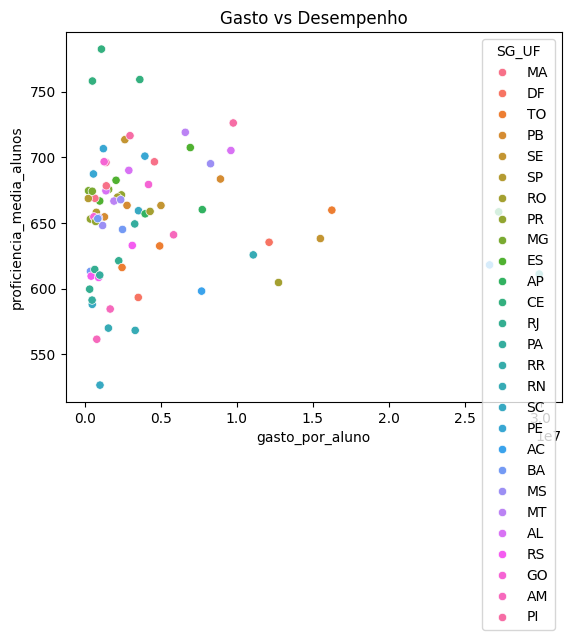

In [0]:
#
import seaborn as sns
import matplotlib.pyplot as plt

df_pd = df_gold.toPandas()

sns.scatterplot(
    data=df_pd,
    x="gasto_por_aluno",
    y="proficiencia_media_alunos",
    hue="SG_UF"
)

plt.title("Gasto vs Desempenho")
plt.show()

In [0]:
#CLUSTERIZAÇÃO (SEGMENTAÇÃO REAL)
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=[
        "total_despesa",
        "total_alunos",
        "proficiencia_media_alunos",
        "gasto_por_aluno"
    ],
    outputCol="features"
)

df_cluster = assembler.transform(df_gold.dropna())


In [0]:
#Treinar modelo
from pyspark.ml.clustering import KMeans

model = KMeans(k=3, seed=42).fit(df_cluster)

df_cluster = model.transform(df_cluster)

In [0]:
#Visualizar clusters
display(df_cluster)

ano,SG_UF,total_despesa,total_alunos,proficiencia_media_alunos,gasto_por_aluno,anomalia,features,prediction
2025,MA,3.3947133631687976E11,74263,696.6381276551336,4571204.184006568,0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""3.3947133631687976E11"",""74263.0"",""696.6381276551336"",""4571204.184006568""]}",1
2025,DF,3.3947133631687976E11,28002,635.3718070962244,1.2123110360577093E7,0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""3.3947133631687976E11"",""28002.0"",""635.3718070962244"",""1.2123110360577093E7""]}",1
2025,TO,3.3947133631687976E11,20883,659.8215730651456,1.6255870148775548E7,0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""3.3947133631687976E11"",""20883.0"",""659.8215730651456"",""1.6255870148775548E7""]}",1
2025,PB,3.3947133631687976E11,38059,683.5152991258324,8919607.354814362,0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""3.3947133631687976E11"",""38059.0"",""683.5152991258324"",""8919607.354814362""]}",1
2025,SE,3.3947133631687976E11,21902,638.1765586319107,1.5499558776224991E7,0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""3.3947133631687976E11"",""21902.0"",""638.1765586319107"",""1.5499558776224991E7""]}",1
2025,SP,3.3947133631687976E11,455929,658.1570728980247,744570.6158565911,0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""3.3947133631687976E11"",""455929.0"",""658.1570728980247"",""744570.6158565911""]}",1
2025,RO,3.3947133631687976E11,26639,604.7207328224059,1.2743396385633085E7,0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""3.3947133631687976E11"",""26639.0"",""604.7207328224059"",""1.2743396385633085E7""]}",1
2025,PR,3.3947133631687976E11,141558,671.4257312415209,2398107.7460608357,0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""3.3947133631687976E11"",""141558.0"",""671.4257312415209"",""2398107.7460608357""]}",1
2025,MG,3.3947133631687976E11,217849,675.6207011418762,1558287.3289153485,0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""3.3947133631687976E11"",""217849.0"",""675.6207011418762"",""1558287.3289153485""]}",1
2025,ES,3.3947133631687976E11,48965,707.451991554287,6932938.554413964,0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""3.3947133631687976E11"",""48965.0"",""707.451991554287"",""6932938.554413964""]}",1


In [0]:
#INTERPRETACAO
#| cluster | perfil |
#|--------|--------|
#| 0 | alto gasto |
#| 1 | moderado |
#| 2 | baixa estrutura |
display(
    df_cluster.groupBy("prediction").agg(
        avg("total_despesa"),
        avg("gasto_por_aluno"),
        avg("proficiencia_media_alunos")
    )
)

prediction,avg(total_despesa),avg(gasto_por_aluno),avg(proficiencia_media_alunos)
1,3.3947133631687976E11,9001423.924119554,665.877696171956
2,4.890169172108999E10,1104871.8863317943,646.9906181747582
0,9.715097232268001E10,2448976.494010015,650.7005498743667


In [0]:
df_ml = df_gold.dropna().select(
    "total_despesa",
    "total_alunos",
    "gasto_por_aluno",
    "proficiencia_media_alunos"
)

In [0]:
#Features
assembler = VectorAssembler(
    inputCols=[
        "total_despesa",
        "total_alunos",
        "gasto_por_aluno"
    ],
    outputCol="features"
)

df_ml = assembler.transform(df_ml)


In [0]:
#Modelo (Regressão)
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(
    featuresCol="features",
    labelCol="proficiencia_media_alunos"
)

model = lr.fit(df_ml)


In [0]:
#PREDIÇÃO
predictions = model.transform(df_ml)

display(predictions.select(
    "proficiencia_media_alunos",
    "prediction"
))

proficiencia_media_alunos,prediction
696.6381276551336,676.6079144760655
635.3718070962244,662.3973786075821
659.8215730651456,653.4263633050465
683.5152991258324,669.0533586118349
638.1765586319107,655.0867215645968
658.1570728980247,660.2971308895699
604.7207328224059,661.070248228842
671.4257312415209,677.1539797555506
675.6207011418762,674.0647189601601
707.451991554287,672.874651238901


In [0]:
#
display(df_gold.filter(col("anomalia") == 1))

ano,SG_UF,total_despesa,total_alunos,proficiencia_media_alunos,gasto_por_aluno,anomalia


links https://portaldatransparencia.gov.br/despesas/funcao?de=01%2F01%2F2025&ate=01%2F12%2F2025&funcaoSubfuncao=FN12&ordenarPor=funcao&direcao=asc

https://qedu.org.br/brasil/censo-escolar/infraestrutura

In [0]:
# =====================================================
# 0. SETUP
# =====================================================

from pyspark.sql import SparkSession
from pyspark.sql.functions import *
import re

spark = SparkSession.builder.getOrCreate()

BASE = "/Volumes/projeto/default/proj_v1"

RAW = f"{BASE}/raw"
BRONZE = f"{BASE}/bronze"
SILVER = f"{BASE}/silver"
GOLD = f"{BASE}/gold"


# =====================================================
# 1. FUNÇÕES AUXILIARES
# =====================================================

def normalizar_colunas(df):

    cols = []
    for c in df.columns:

        c = c.lower()
        c = re.sub(r'[áàãâä]', 'a', c)
        c = re.sub(r'[éèêë]', 'e', c)
        c = re.sub(r'[íìîï]', 'i', c)
        c = re.sub(r'[óòõôö]', 'o', c)
        c = re.sub(r'[úùûü]', 'u', c)
        c = re.sub(r'ç', 'c', c)

        c = re.sub(r'[^a-z0-9_]', '_', c)
        c = re.sub(r'_+', '_', c)
        c = c.strip("_")

        cols.append(c)

    return df.toDF(*cols)


def remover_colunas_invalidas(df):
    return df.select([c for c in df.columns if not c.startswith("c")])


# =====================================================
# 2. RAW → BRONZE (STREAMING)
# =====================================================

df_raw = (
    spark.readStream
    .format("cloudFiles")
    .option("cloudFiles.format", "csv")
    .option("header", True)
    .option("delimiter", ";")  # ✅ CSV brasileiro
    .load(RAW)
)

# limpeza
df_bronze = normalizar_colunas(df_raw)
df_bronze = remover_colunas_invalidas(df_bronze)

# adicionar metadata básica
df_bronze = df_bronze.withColumn("ingestion_time", current_timestamp())

# escrever BRONZE
query_bronze = (
    df_bronze.writeStream
    .format("delta")
    .option("checkpointLocation", f"{BRONZE}/chk")
    .outputMode("append")
    .start(f"{BRONZE}/DESPESAS")
)

# =====================================================
# 3. BRONZE → SILVER (STREAMING + DATA QUALITY)
# =====================================================

df_bronze_stream = spark.readStream.format("delta").load(f"{BRONZE}/DESPESAS")

df_silver = (
    df_bronze_stream
    .dropna(subset=["valor_empenhado"])  # ✅ nulos críticos
    .dropDuplicates()
    .withColumn(
        "valor_empenhado",
        when(col("valor_empenhado") < 0, 0)
        .otherwise(col("valor_empenhado"))
    )
)

query_silver = (
    df_silver.writeStream
    .format("delta")
    .option("checkpointLocation", f"{SILVER}/chk")
    .outputMode("append")
    .start(f"{SILVER}/DESPESAS")
)

# =====================================================
# 4. SILVER → GOLD (STREAMING AGGREGATION)
# =====================================================

df_silver_stream = spark.readStream.format("delta").load(f"{SILVER}/DESPESAS")

df_gold_stream = (
    df_silver_stream
    .groupBy("ano", "sg_uf")
    .agg(
        sum("valor_empenhado").alias("total_despesa"),
        count("*").alias("total_registros")
    )
)

query_gold = (
    df_gold_stream.writeStream
    .format("delta")
    .option("checkpointLocation", f"{GOLD}/chk")
    .outputMode("complete")  # agregação streaming
    .start(f"{GOLD}/ANALYTICS")
)

# =====================================================
# 5. STREAMING MONITOR (IMPORTANTE)
# =====================================================

query_bronze.awaitTermination()
query_silver.awaitTermination()
query_gold.awaitTermination()